# 02 · EDA, feature engineering y modelado



En este notebook se realiza el análisis exploratorio (EDA), la ingeniería de variables y el modelado inicial del problema de predicción de la gravedad de los accidentes.

En primer lugar, se lleva a cabo una revisión y tipado de variables, asegurando que los datos estén en el formato adecuado para el análisis y el modelado.

A continuación, se desarrolla un análisis exploratorio de los datos, donde se estudian relaciones entre variables (como hora, condiciones meteorológicas, etc.) y la variable objetivo gravedad, con el objetivo de identificar patrones relevantes.

Posteriormente, se realiza feature engineering adicional, incluyendo transformaciones y selección de variables para mejorar la capacidad predictiva del modelo.

En la fase de modelado, se construye un modelo baseline utilizando validación cruzada, que permite establecer un punto de referencia para evaluar el rendimiento.

Finalmente, se evalúa el modelo mediante métricas como precisión, recall y F1-score, así como una matriz de confusión, lo que permite analizar en detalle el comportamiento del modelo y sus errores.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [3]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.1 MB/s eta 0:00:00


In [4]:
import category_encoders as ce

## 1. Carga de datos procesados

In [5]:
DATA_PATH = "/content/drive/MyDrive/Proyecto final Keepcoding/datasets/processed data/accidentes_madrid_procesado.csv"

df_acc = pd.read_csv(DATA_PATH)
print(df_acc.shape)
df_acc.head()

(67542, 52)


,num_expediente,gravedad,fecha,hora,distrito,estado_meteorológico,temperature_2m,precipitation,windspeed_10m,coordenada_x_utm,coordenada_y_utm,alcohol_positivo,edad_media,dia_semana,mes,vehiculo_coche,vehiculo_moto,vehiculo_bici_patinete,vehiculo_bus,vehiculo_furgoneta,vehiculo_pesado,vehiculo_especial,vehiculo_otros,tipo_accidente_Alcance,tipo_accidente_Atropello a animal,tipo_accidente_Atropello a persona,tipo_accidente_Caída,tipo_accidente_Choque contra obstáculo fijo,tipo_accidente_Colisión frontal,tipo_accidente_Colisión fronto-lateral,tipo_accidente_Colisión lateral,tipo_accidente_Colisión múltiple,tipo_accidente_Despeñamiento,tipo_accidente_NaN,tipo_accidente_Otro,tipo_accidente_Solo salida de la vía,tipo_accidente_Vuelco,sexo_Desconocido,sexo_Hombre,sexo_Mujer,tipo_persona_Conductor,tipo_persona_NaN,tipo_persona_Pasajero,tipo_persona_Peatón,tipo_persona_Peatón (atropello sc),fecha_date,festivo,estacion,fin_semana,hora_punta,noche,franja_horaria
0,2020S000006,0,2020-01-01,5,CARABANCHEL,Despejado,0.2,0.0,6.6,436672.459,4470217.076,1,32.5,2,1,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,2020-01-01,1,invierno,0,0,1,madrugada
1,2020S000007,1,2020-01-01,6,SALAMANCA,Despejado,-0.6,0.0,6.1,443740.487,4475559.889,0,32.0,2,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,2020-01-01,1,invierno,0,0,1,madrugada
2,2020S000015,0,2020-01-01,2,CHAMARTÍN,Despejado,1.3,0.0,7.2,441461.761,4478393.729,0,39.5,2,1,4,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,2020-01-01,1,invierno,0,0,1,madrugada
3,2020S000017,0,2020-01-01,3,PUENTE DE VALLECAS,Despejado,1.5,0.0,6.2,442141.822,4469512.270,0,37.0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,2020-01-01,1,invierno,0,0,1,madrugada
4,2020S000020,1,2020-01-01,9,CARABANCHEL,Despejado,-1.6,0.0,7.4,439691.436,4471512.665,0,27.0,2,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,2020-01-01,1,invierno,0,1,0,mañana


## 2. Tipado y revisión rápida

In [6]:
df_acc["fecha"] = pd.to_datetime(df_acc["fecha"], errors="coerce")
for c in ["gravedad", "hora", "dia_semana", "mes", "alcohol_positivo",
          "vehiculo_coche", "vehiculo_moto", "vehiculo_bici_patinete",
          "vehiculo_bus", "vehiculo_furgoneta", "vehiculo_pesado",
          "vehiculo_especial", "vehiculo_otros", "festivo", "hora_punta", "noche"]:
    if c in df_acc.columns:
        df_acc[c] = pd.to_numeric(df_acc[c], errors="coerce")

display(df_acc.info())
display((df_acc.isnull().mean() * 100).sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67542 entries, 0 to 67541
Data columns (total 52 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   num_expediente                               67542 non-null  object        
 1   gravedad                                     67542 non-null  int64         
 2   fecha                                        67542 non-null  datetime64[ns]
 3   hora                                         67542 non-null  int64         
 4   distrito                                     67539 non-null  object        
 5   estado_meteorológico                         65469 non-null  object        
 6   temperature_2m                               67542 non-null  float64       
 7   precipitation                                67542 non-null  float64       
 8   windspeed_10m                                67542 non-null  float64       


None

,0
estado_meteorológico,3.069201
distrito,0.004442
num_expediente,0.000000
gravedad,0.000000
hora,0.000000
fecha,0.000000
temperature_2m,0.000000
precipitation,0.000000
windspeed_10m,0.000000
coordenada_x_utm,0.000000


## 3. EDA

,proportion
gravedad,
0,0.222958
1,0.777042


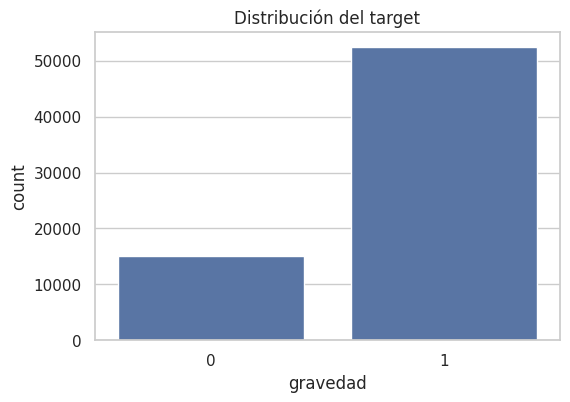

In [7]:
display(df_acc["gravedad"].value_counts(normalize=True).sort_index())

plt.figure(figsize=(6,4))
sns.countplot(data=df_acc, x="gravedad")
plt.title("Distribución del target")
plt.show()

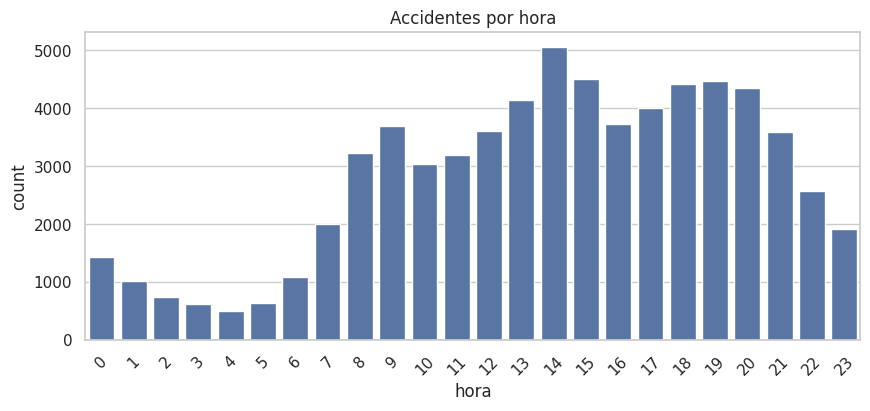

In [8]:
plt.figure(figsize=(10,4))
sns.countplot(data=df_acc, x="hora")
plt.title("Accidentes por hora")
plt.xticks(rotation=45)
plt.show()

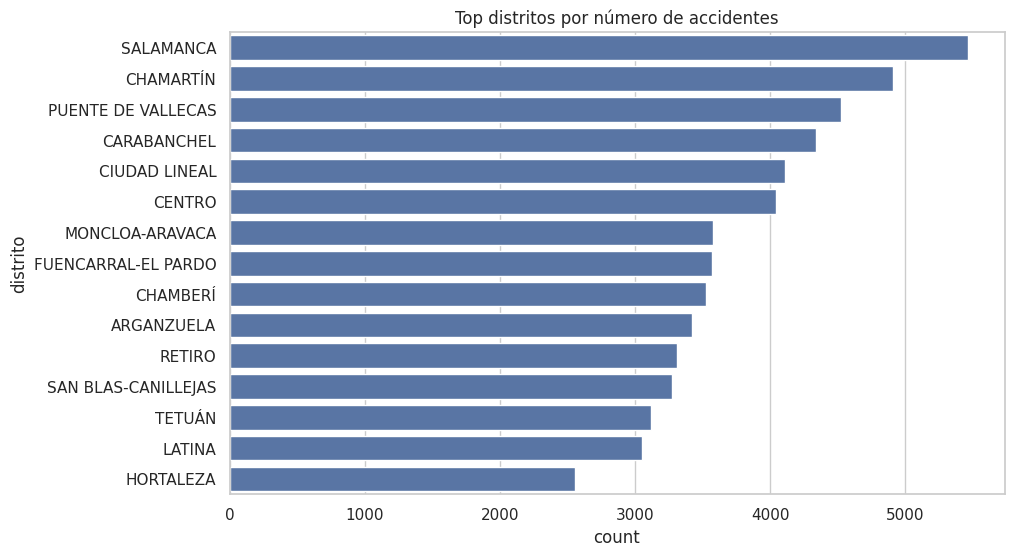

In [9]:
top_distritos = df_acc["distrito"].value_counts().head(15).index
plt.figure(figsize=(10,6))
sns.countplot(data=df_acc[df_acc["distrito"].isin(top_distritos)], y="distrito",
              order=df_acc["distrito"].value_counts().head(15).index)
plt.title("Top distritos por número de accidentes")
plt.show()


Relacion Gravedad de accidentes con clima

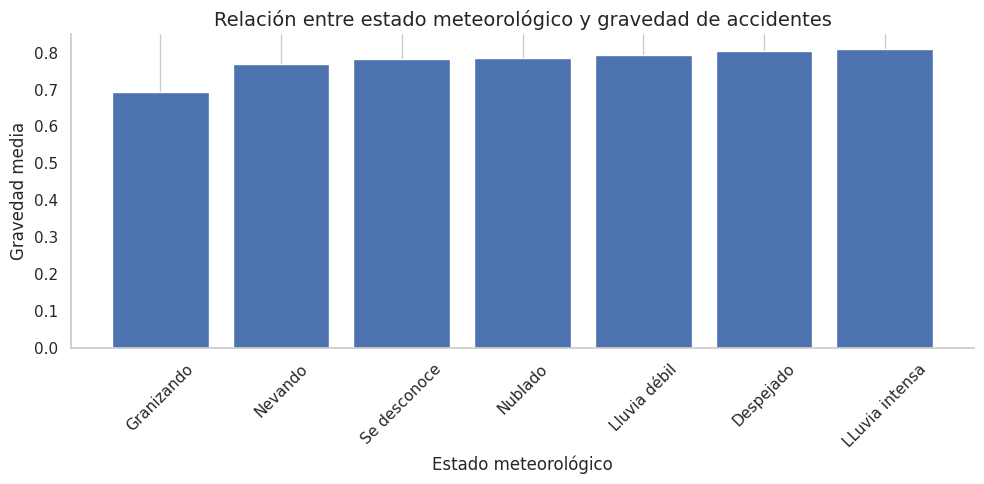

In [10]:
import matplotlib.pyplot as plt

# Agrupar por clima
gravedad_por_clima = df_acc.groupby("estado_meteorológico")["gravedad"].mean()

# Ordenar para que se vea mejor (opcional pero recomendable)
gravedad_por_clima = gravedad_por_clima.sort_values()

# Crear figura
plt.figure(figsize=(10, 5))

# Gráfico de barras
plt.bar(gravedad_por_clima.index, gravedad_por_clima.values)

# Títulos
plt.title("Relación entre estado meteorológico y gravedad de accidentes", fontsize=14)
plt.xlabel("Estado meteorológico", fontsize=12)
plt.ylabel("Gravedad media", fontsize=12)

# Rotar etiquetas (MUY importante aquí)
plt.xticks(rotation=45)

# Grid suave
plt.grid(axis='y')

# Quitar bordes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Ajustar layout
plt.tight_layout()

# Mostrar
plt.show()

Relacion gravedad por hora

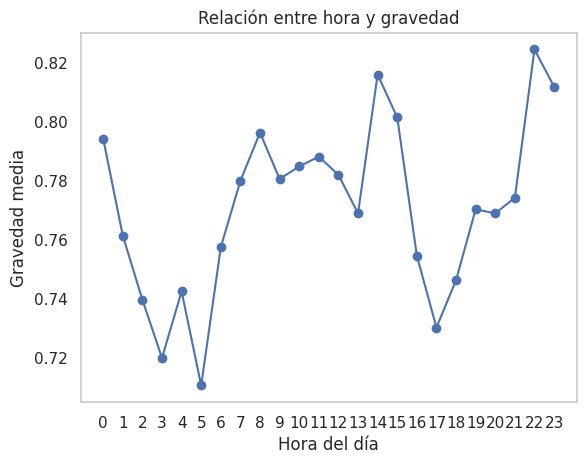

In [11]:
gravedad_por_hora = df_acc.groupby("hora")["gravedad"].mean()
# Crear gráfico
plt.figure()
plt.plot(gravedad_por_hora.index, gravedad_por_hora.values, marker='o')

# Etiquetas
plt.xlabel("Hora del día")
plt.ylabel("Gravedad media")
plt.title("Relación entre hora y gravedad")

# Mejor visualización
plt.xticks(range(24))
plt.grid()

# Mostrar gráfico
plt.show()

Se analiza la correlación entre variables para identificar posibles relaciones de multicolinealidad.

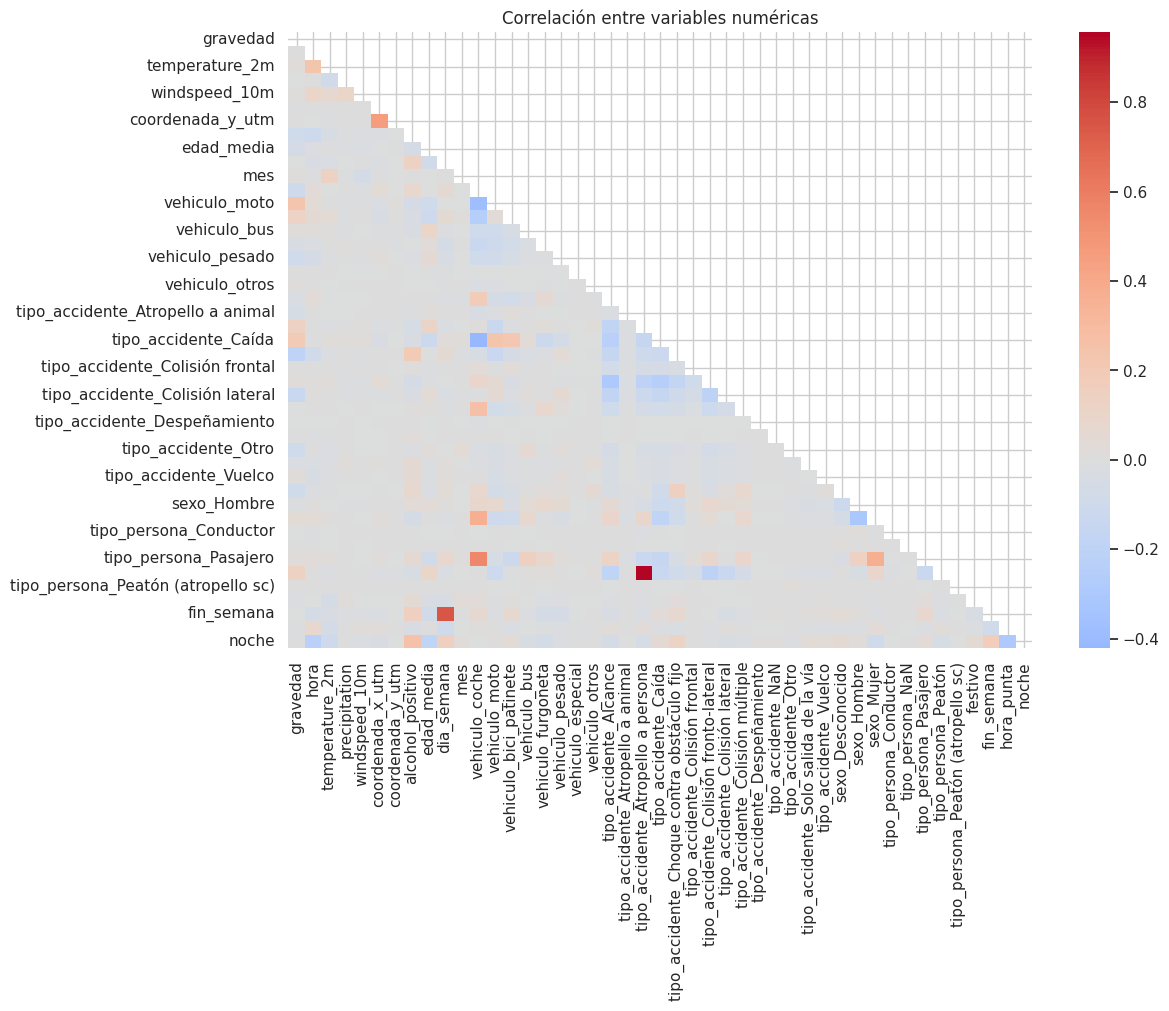

In [12]:
num_cols = df_acc.select_dtypes(include=["number", "bool"]).columns.tolist()
corr = df_acc[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0)
plt.title("Correlación entre variables numéricas")
plt.show()

## 4. Features adicionales previas al split

In [13]:
# Se unifican etiquetas raras del clima
if "estado_meteorológico" in df_acc.columns:
    df_acc["estado_meteorológico"] = df_acc["estado_meteorológico"].replace({
        "Se desconoce": "Desconocido"
    })

# Features de interacción no supervisadas
df_acc["noche_x_alcohol"] = df_acc["noche"] * df_acc["alcohol_positivo"]
df_acc["lluvia_x_hora"] = df_acc["precipitation"] * df_acc["hora"]
df_acc["fin_semana_x_noche"] = df_acc["fin_semana"] * df_acc["noche"]
df_acc["hora_peligrosa"] = df_acc["hora"].isin([0, 1, 2, 3, 4]).astype(int)

df_acc.head()

,num_expediente,gravedad,fecha,hora,distrito,estado_meteorológico,temperature_2m,precipitation,windspeed_10m,coordenada_x_utm,coordenada_y_utm,alcohol_positivo,edad_media,dia_semana,mes,vehiculo_coche,vehiculo_moto,vehiculo_bici_patinete,vehiculo_bus,vehiculo_furgoneta,vehiculo_pesado,vehiculo_especial,vehiculo_otros,tipo_accidente_Alcance,tipo_accidente_Atropello a animal,tipo_accidente_Atropello a persona,tipo_accidente_Caída,tipo_accidente_Choque contra obstáculo fijo,tipo_accidente_Colisión frontal,tipo_accidente_Colisión fronto-lateral,tipo_accidente_Colisión lateral,tipo_accidente_Colisión múltiple,tipo_accidente_Despeñamiento,tipo_accidente_NaN,tipo_accidente_Otro,tipo_accidente_Solo salida de la vía,tipo_accidente_Vuelco,sexo_Desconocido,sexo_Hombre,sexo_Mujer,tipo_persona_Conductor,tipo_persona_NaN,tipo_persona_Pasajero,tipo_persona_Peatón,tipo_persona_Peatón (atropello sc),fecha_date,festivo,estacion,fin_semana,hora_punta,noche,franja_horaria,noche_x_alcohol,lluvia_x_hora,fin_semana_x_noche,hora_peligrosa
0,2020S000006,0,2020-01-01,5,CARABANCHEL,Despejado,0.2,0.0,6.6,436672.459,4470217.076,1,32.5,2,1,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,2020-01-01,1,invierno,0,0,1,madrugada,1,0.0,0,0
1,2020S000007,1,2020-01-01,6,SALAMANCA,Despejado,-0.6,0.0,6.1,443740.487,4475559.889,0,32.0,2,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,2020-01-01,1,invierno,0,0,1,madrugada,0,0.0,0,0
2,2020S000015,0,2020-01-01,2,CHAMARTÍN,Despejado,1.3,0.0,7.2,441461.761,4478393.729,0,39.5,2,1,4,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,2020-01-01,1,invierno,0,0,1,madrugada,0,0.0,0,1
3,2020S000017,0,2020-01-01,3,PUENTE DE VALLECAS,Despejado,1.5,0.0,6.2,442141.822,4469512.270,0,37.0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,2020-01-01,1,invierno,0,0,1,madrugada,0,0.0,0,1
4,2020S000020,1,2020-01-01,9,CARABANCHEL,Despejado,-1.6,0.0,7.4,439691.436,4471512.665,0,27.0,2,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,2020-01-01,1,invierno,0,1,0,mañana,0,0.0,0,0


## 5. Separación de variables y target

Se quitan columnas no útiles directamente para el modelo:
- `num_expediente`: identificador
- `fecha`: la fecha exacta suele meter ruido ya que se ha derivado mes/día/etc.
- `fecha_date`: auxiliar

In [14]:
drop_cols = [c for c in ["num_expediente", "fecha", "fecha_date"] if c in df_acc.columns]
X = df_acc.drop(columns=drop_cols + ["gravedad"])
y = df_acc["gravedad"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (54033, 52) (54033,)
Test: (13509, 52) (13509,)


## 6. Target encoding y one-hot sin leakage

In [15]:
# Target encoding para distrito
if "distrito" in X_train.columns:
    te_distrito = ce.TargetEncoder(cols=["distrito"], smoothing=10)
    X_train["distrito"] = te_distrito.fit_transform(X_train["distrito"], y_train)
    X_test["distrito"] = te_distrito.transform(X_test["distrito"])

# Target encoding para franja_horaria
if "franja_horaria" in X_train.columns:
    te_franja = ce.TargetEncoder(cols=["franja_horaria"], smoothing=10)
    X_train["franja_horaria"] = te_franja.fit_transform(X_train["franja_horaria"], y_train)
    X_test["franja_horaria"] = te_franja.transform(X_test["franja_horaria"])

# One-hot para variables categóricas restantes
cat_cols = [c for c in ["estacion", "estado_meteorológico"] if c in X_train.columns]

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype=int)

# Alinear columnas train/test
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(X_train.shape, X_test.shape)

(54033, 59) (13509, 59)


## 7. Riesgo espacial por clustering (sin leakage)

Para evitar data leakage, las variables derivadas que dependen del target se calculan únicamente con el conjunto de entrenamiento y luego se aplican al conjunto de test, asegurando que el modelo no utilice información del conjunto de evaluación

In [16]:
coords_cols = ["coordenada_x_utm", "coordenada_y_utm"]

if all(c in X_train.columns for c in coords_cols):
    kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)

    X_train["zona_riesgo"] = kmeans.fit_predict(X_train[coords_cols])
    X_test["zona_riesgo"] = kmeans.predict(X_test[coords_cols])

    tmp_train = X_train.copy()
    tmp_train["gravedad"] = y_train.values

    zona_riesgo_mean = tmp_train.groupby("zona_riesgo")["gravedad"].mean()

    global_mean = y_train.mean()
    X_train["riesgo_zona"] = X_train["zona_riesgo"].map(zona_riesgo_mean).fillna(global_mean)
    X_test["riesgo_zona"] = X_test["zona_riesgo"].map(zona_riesgo_mean).fillna(global_mean)

    X_train = X_train.drop(columns=["zona_riesgo"])
    X_test = X_test.drop(columns=["zona_riesgo"])

X_train.head()

,hora,distrito,temperature_2m,precipitation,windspeed_10m,coordenada_x_utm,coordenada_y_utm,alcohol_positivo,edad_media,dia_semana,mes,vehiculo_coche,vehiculo_moto,vehiculo_bici_patinete,vehiculo_bus,vehiculo_furgoneta,vehiculo_pesado,vehiculo_especial,vehiculo_otros,tipo_accidente_Alcance,tipo_accidente_Atropello a animal,tipo_accidente_Atropello a persona,tipo_accidente_Caída,tipo_accidente_Choque contra obstáculo fijo,tipo_accidente_Colisión frontal,tipo_accidente_Colisión fronto-lateral,tipo_accidente_Colisión lateral,tipo_accidente_Colisión múltiple,tipo_accidente_Despeñamiento,tipo_accidente_NaN,tipo_accidente_Otro,tipo_accidente_Solo salida de la vía,tipo_accidente_Vuelco,sexo_Desconocido,sexo_Hombre,sexo_Mujer,tipo_persona_Conductor,tipo_persona_NaN,tipo_persona_Pasajero,tipo_persona_Peatón,tipo_persona_Peatón (atropello sc),festivo,fin_semana,hora_punta,noche,franja_horaria,noche_x_alcohol,lluvia_x_hora,fin_semana_x_noche,hora_peligrosa,estacion_otoño,estacion_primavera,estacion_verano,estado_meteorológico_Despejado,estado_meteorológico_Granizando,estado_meteorológico_LLuvia intensa,estado_meteorológico_Lluvia débil,estado_meteorológico_Nevando,estado_meteorológico_Nublado,riesgo_zona
44832,18,0.776158,22.4,0.0,2.3,436010.200,4468554.046,0,49.5,4,4,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0.771475,0,0.0,0,0,0,1,0,1,0,0,0,0,0,0.773211
53004,17,0.776158,12.0,0.0,2.8,439471.703,4472015.616,1,47.0,6,12,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,0,1,0,0,0,1,0,0,0.771475,0,0.0,0,0,0,0,0,1,0,0,0,0,0,0.807844
19356,7,0.770161,0.9,0.0,5.2,441222.641,4468839.525,0,52.0,3,2,0,0,0,0,0,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0.785322,0,0.0,0,0,0,0,0,1,0,0,0,0,0,0.763330
1004,15,0.754348,14.5,0.0,12.2,443121.548,4472075.701,0,39.5,4,1,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0.771475,0,0.0,0,0,0,0,0,1,0,0,0,0,0,0.756799
52856,12,0.730734,4.4,0.0,2.4,442517.931,4474775.907,0,49.5,4,12,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0.785322,0,0.0,0,0,0,0,0,0,0,0,0,0,1,0.764287


## 8. Limpieza final de columnas

In [17]:
# Se quedan solo con columnas numéricas/bool
X_train = X_train.select_dtypes(include=["number", "bool"]).copy()
X_test = X_test.select_dtypes(include=["number", "bool"]).copy()

# Nombres limpios para evitar problemas en algunos modelos
def limpiar_nombres_columnas(cols):
    return (
        cols.astype(str)
            .str.replace(r"[^0-9a-zA-Z_]+", "_", regex=True)
            .str.replace(r"_+", "_", regex=True)
            .str.strip("_")
    )

X_train.columns = limpiar_nombres_columnas(X_train.columns)
X_test.columns = limpiar_nombres_columnas(X_test.columns)

# Última alineación por seguridad
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(X_train.shape, X_test.shape)
display(X_train.dtypes.head())

(54033, 60) (13509, 60)


,0
hora,int64
distrito,float64
temperature_2m,float64
precipitation,float64
windspeed_10m,float64


## 9. Baseline con validación cruzada

In [18]:
# SMOTE se aplica solo en train dentro de cada fold para evitar data leakage
class_counts = y_train.value_counts().sort_index().to_dict()
max_count = max(class_counts.values())

sampling_strategy = {}
for cls, cnt in class_counts.items():
    if cnt < max_count:
        sampling_strategy[cls] = min(max_count, cnt * 2)

pipeline_base = Pipeline([
    ("smote", SMOTE(sampling_strategy=sampling_strategy, random_state=42)),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

scores = cross_val_score(
    pipeline_base,
    X_train,
    y_train,
    scoring="f1_macro",
    cv=5,
    n_jobs=1
)

print("F1 macro por fold:", scores)
print("F1 macro medio:", scores.mean())

F1 macro por fold: [0.70775564 0.71378614 0.70827985 0.71552952 0.71354905]
F1 macro medio: 0.7117800374022074


## 10. GridSearch: Random Forest

In [19]:
pipeline_rf = Pipeline([
    ("smote", SMOTE(sampling_strategy=sampling_strategy, random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__class_weight": ["balanced"]
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_rf,
    scoring="f1_macro",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV F1 macro:", grid_rf.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END model__class_weight=balanced, model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   5.3s
[CV] END model__class_weight=balanced, model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   3.8s
[CV] END model__class_weight=balanced, model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   3.3s
[CV] END model__class_weight=balanced, model__max_depth=5, model__min_samples_split=2, model__n_estimators=200; total time=   8.6s
[CV] END model__class_weight=balanced, model__max_depth=5, model__min_samples_split=2, model__n_estimators=200; total time=   6.2s
[CV] END model__class_weight=balanced, model__max_depth=5, model__min_samples_split=2, model__n_estimators=200; total time=   7.1s
[CV] END model__class_weight=balanced, model__max_depth=5, model__min_samples_split=5, model__n_estimators=100; total time=   4.5s
[CV] END model__class_

## 11. GridSearch: Gradient Boosting

In [20]:
pipeline_gb = Pipeline([
    ("smote", SMOTE(sampling_strategy=sampling_strategy, random_state=42)),
    ("model", GradientBoostingClassifier(random_state=42))
])

param_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5]
}

grid_gb = GridSearchCV(
    pipeline_gb,
    param_gb,
    scoring="f1_macro",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_

print("Best GB params:", grid_gb.best_params_)
print("Best GB CV F1 macro:", grid_gb.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100; total time=  25.5s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100; total time=  24.1s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100; total time=  25.2s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200; total time=  47.9s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200; total time=  50.1s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200; total time=  48.8s
[CV] END model__learning_rate=0.05, model__max_depth=5, model__n_estimators=100; total time=  41.9s
[CV] END model__learning_rate=0.05, model__max_depth=5, model__n_estimators=100; total time=  41.6s
[CV] END model__learning_rate=0.05, model__max_depth=5, model__n_estimators=100; total time=  41.5s
[CV] END model__learning_rate=0.05, mode

## 13. Comparación de modelos

In [21]:
resultados_cv = {
    "RandomForest": grid_rf.best_score_,
    "GradientBoosting": grid_gb.best_score_,
}


resultados_cv = pd.Series(resultados_cv).sort_values(ascending=False)
display(resultados_cv)
best_model_name = resultados_cv.index[0]
print("Mejor modelo por CV:", best_model_name)

,0
GradientBoosting,0.725979
RandomForest,0.716901


Mejor modelo por CV: GradientBoosting


## Evaluación y comparación de modelos

Se han comparado los modelos Random Forest y Gradient Boosting utilizando validación cruzada y la métrica F1-score.

Los resultados muestran que:

- Gradient Boosting obtiene un F1-score de 0.726
- Random Forest obtiene un F1-score de 0.717

El modelo Gradient Boosting presenta un rendimiento ligeramente superior, lo que indica una mejor capacidad para capturar relaciones complejas entre las variables.

Aunque la diferencia no es muy elevada, se considera que Gradient Boosting es el modelo más adecuado para este problema, ya que ofrece un mejor equilibrio entre precisión y generalización.

Este resultado sugiere que las relaciones entre las variables que afectan a la gravedad de los accidentes no son completamente lineales, y requieren modelos capaces de capturar interacciones más complejas.

In [22]:
if best_model_name == "RandomForest":
    best_model = best_rf
elif best_model_name == "GradientBoosting":
    best_model = best_gb

Ajuste de threshold

In [23]:
# Probabilidades en TRAIN (NO test)
y_proba_train = best_model.predict_proba(X_train)[:, 1]

# Ajuste del threshold de decisión

Dado que el problema presenta desbalanceo de clases y el objetivo es optimizar métricas como el F1-score, se ha realizado un ajuste del threshold de decisión del modelo.

En lugar de utilizar el valor por defecto (0.5), se ha definido un rango de posibles umbrales entre 0.1 y 0.9, evaluando el rendimiento del modelo para cada uno de ellos. Para cada threshold, se transforman las probabilidades predichas en clases binarias y se calcula la métrica objetivo.

Finalmente, se selecciona el threshold que maximiza el F1-score, obteniendo así un equilibrio óptimo entre precisión (precision) y exhaustividad (recall).

In [24]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)

best_thresh = 0.5
best_score = 0

for t in thresholds:
    y_pred_t = (y_proba_train >= t).astype(int)
    score = f1_score(y_train, y_pred_t, average="macro")

    if score > best_score:
        best_score = score
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1 macro (train):", best_score)

Best threshold: 0.589795918367347
Best F1 macro (train): 0.7730728630246744


Se ajustó el umbral de decisión para equilibrar la capacidad del modelo entre ambas clases, mejorando la detección de accidentes no graves sin comprometer significativamente la detección de accidentes graves.

## 14. Evaluación en test

In [25]:
# Probabilidades en TEST
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Aplicar threshold óptimo
y_pred_opt = (y_proba_test >= best_thresh).astype(int)

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.61      0.56      0.58      3012
           1       0.88      0.90      0.89     10497

    accuracy                           0.82     13509
   macro avg       0.74      0.73      0.73     13509
weighted avg       0.82      0.82      0.82     13509



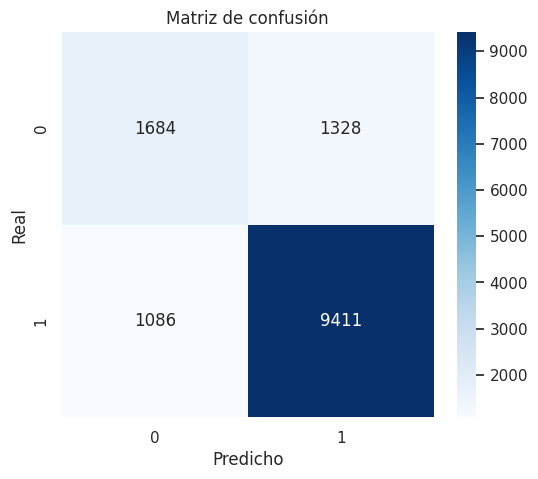

In [27]:
cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

## Análisis de resultados del modelo

El modelo presenta un buen rendimiento general, con una precisión global del 82%. Sin embargo, el análisis detallado por clases muestra diferencias relevantes.

En la clase de accidentes graves (1), el modelo obtiene un F1-score de 0.89, lo que indica una alta capacidad para identificar correctamente este tipo de accidentes. Esto es especialmente relevante desde el punto de vista del negocio, ya que permite detectar con fiabilidad los casos más críticos.

Por el contrario, en la clase de accidentes no graves (0), el rendimiento es inferior (F1-score de 0.58), lo que indica que el modelo tiene mayor dificultad para distinguir correctamente estos casos.

El análisis de la matriz de confusión confirma este comportamiento:

- El modelo identifica correctamente un gran número de accidentes graves
- Existe una cantidad significativa de falsos positivos (clasifica como grave un accidente que no lo es)
- También se observan falsos negativos, aunque en menor medida

Este comportamiento sugiere que el modelo está sesgado hacia la detección de accidentes graves, lo cual puede ser aceptable dependiendo del contexto de aplicación.

Desde el punto de vista operativo, este sesgo puede ser incluso deseable, ya que es preferible sobreestimar la gravedad de un accidente (falso positivo) que no detectar un accidente grave (falso negativo), especialmente en la asignación de recursos médicos.

No obstante, este comportamiento debe ser tenido en cuenta en la interpretación de los resultados y en el uso del modelo en un entorno real.

## 15. Importancia de variables

Esto funciona si el mejor modelo es de árboles.

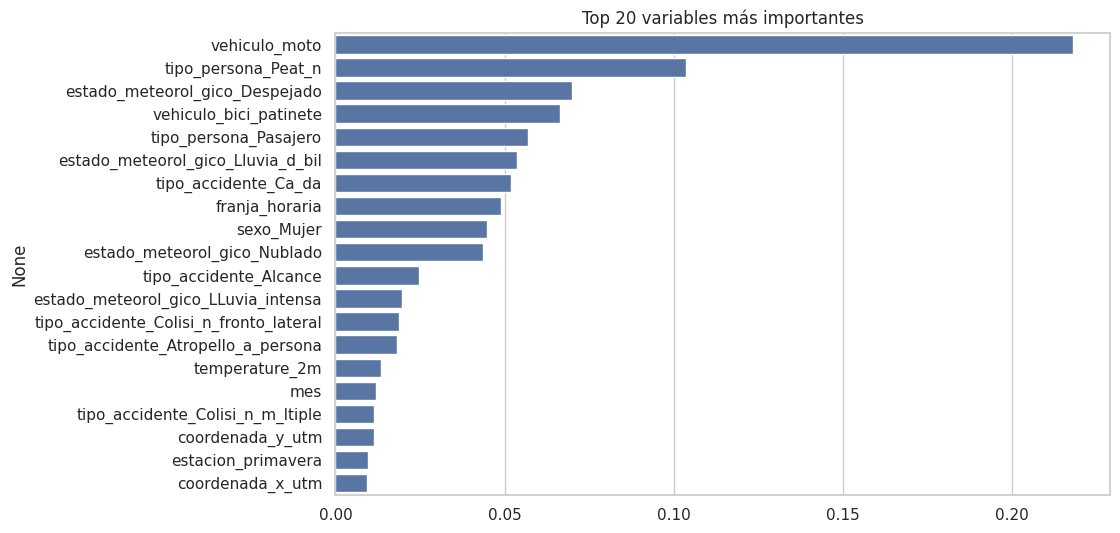

,0
vehiculo_moto,0.218098
tipo_persona_Peat_n,0.103609
estado_meteorol_gico_Despejado,0.070067
vehiculo_bici_patinete,0.066491
tipo_persona_Pasajero,0.057034
estado_meteorol_gico_Lluvia_d_bil,0.053620
tipo_accidente_Ca_da,0.051820
franja_horaria,0.048857
sexo_Mujer,0.044896
estado_meteorol_gico_Nublado,0.043665


In [28]:
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feat_imp = (
        pd.Series(model_step.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10,6))
    sns.barplot(x=feat_imp.values, y=feat_imp.index)
    plt.title("Top 20 variables más importantes")
    plt.show()

    display(feat_imp)
else:
    print("El modelo seleccionado no expone feature_importances_.")

## Importancia de variables

El análisis de la importancia de variables permite identificar qué factores tienen mayor influencia en la predicción de la gravedad de los accidentes.

Los resultados muestran que:

- El tipo de vehículo es el factor más relevante, destacando especialmente la presencia de motocicletas como variable con mayor impacto.
- El tipo de persona implicada también es determinante, siendo los peatones uno de los grupos con mayor influencia en la gravedad.
- Las condiciones meteorológicas tienen un peso significativo, lo que refuerza su papel en la severidad de los accidentes.
- Los vehículos vulnerables, como bicicletas y patinetes, también contribuyen de forma relevante.
- El tipo de accidente (caídas, colisiones, atropellos) influye directamente en el nivel de gravedad.

Por otro lado, variables como la localización o la estación del año presentan una menor importancia relativa en el modelo.

En conjunto, estos resultados indican que la gravedad de los accidentes está principalmente asociada a factores relacionados con la vulnerabilidad de los implicados y las condiciones del entorno, más que a la ubicación específica del accidente.

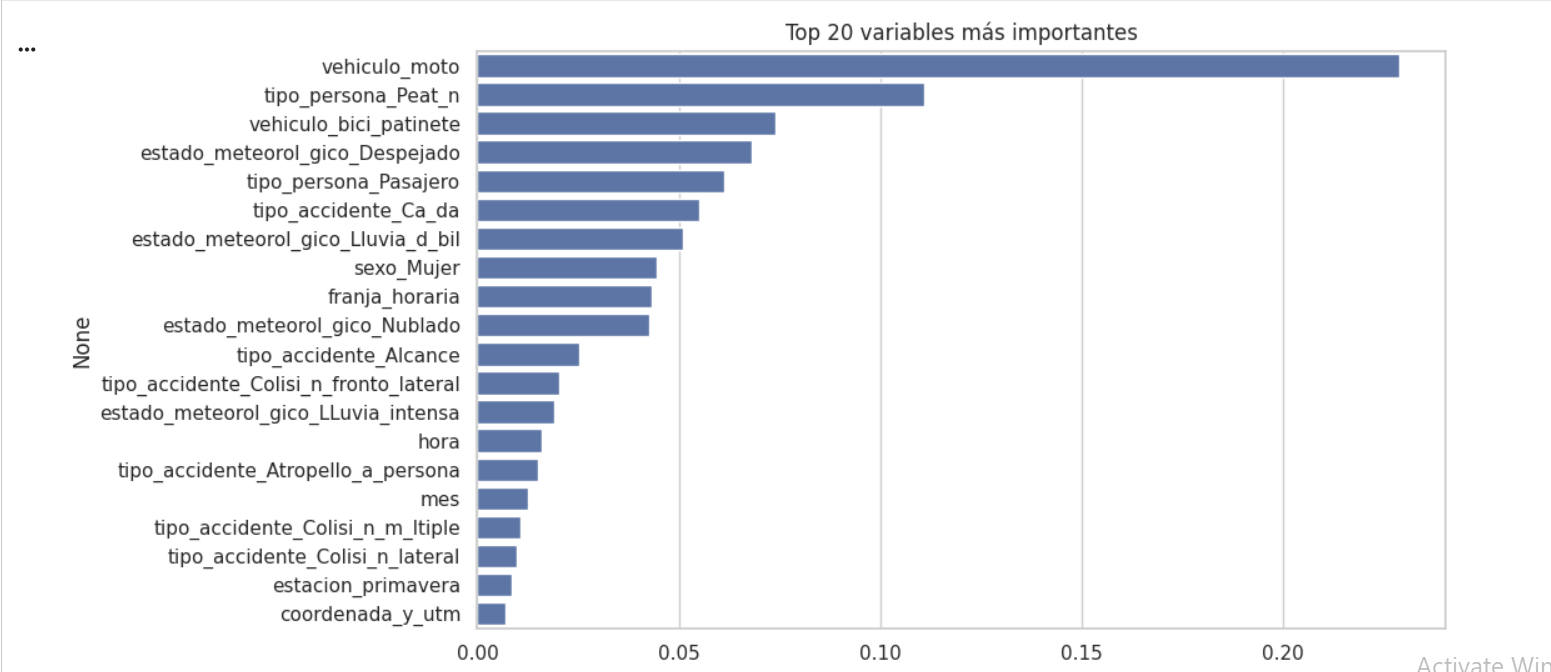

# Validación de hipotesis
Los resultados muestran que la gravedad de los accidentes está principalmente determinada por el tipo de implicado (peatones) y el tipo de vehículo (especialmente motocicletas), mientras que factores contextuales como el clima, la hora o el consumo de alcohol tienen un impacto menor o no concluyente en este dataset.

## 16. Guardado del modelo final

Se usa `joblib` para guardar el mejor pipeline completo.

In [29]:
import joblib
joblib.dump(best_model, "/content/drive/MyDrive/Proyecto final Keepcoding/Final model/mejor_modelo.pkl")

print("Modelo guardado con exito.")

Modelo guardado con exito.
